In [ ]:
!pip install transformers pandas matplotlib -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

# dataset_dir = "/content/drive/MyDrive/datasets-shared-by-NIC"
# datasets = {}


# for file in os.listdir(dataset_dir):
#     if file.endswith(".csv"):
#         file_path = os.path.join(dataset_dir, file)
#         dataset_name = os.path.splitext(file)[0]
#         df = pd.read_csv(file_path, encoding='utf-8')
#         datasets[dataset_name] = df


# Folder path containing all your CSV files
import os
import pandas as pd

# Root folder path containing all CSVs and subfolders
folder_path = "/content/drive/MyDrive/datasets-shared-by-NIC/downloaded-datasets"

# Dictionary to hold dataset name and DataFrame
datasets = {}

# Walk through all subdirectories and files
for root, dirs, files in os.walk(folder_path):
    for file_name in files:
        if file_name.lower().endswith(".csv"):
            file_path = os.path.join(root, file_name)
            dataset_name = os.path.splitext(file_name)[0]  # filename without extension

            try:
                # Try reading as UTF-8
                df = pd.read_csv(file_path, encoding="utf-8")
            except UnicodeDecodeError:
                print(f"UTF-8 failed for {file_name}, trying latin1...")
                df = pd.read_csv(file_path, encoding="latin1")
            except Exception as e:
                print(f"Failed to read {file_name}: {e}")
                continue

            datasets[dataset_name] = df

print(f"Loaded {len(datasets)} datasets successfully:")
print(list(datasets.keys()))


Failed to read 2013.csv: No columns to parse from file
Failed to read 2012.csv: No columns to parse from file
Failed to read 2006.csv: No columns to parse from file
Failed to read 2008.csv: No columns to parse from file
Failed to read 2015.csv: No columns to parse from file
Failed to read 2007.csv: No columns to parse from file
Failed to read 2016.csv: No columns to parse from file
Failed to read 2007.csv: No columns to parse from file
Failed to read 2006.csv: No columns to parse from file
Failed to read 2006.csv: No columns to parse from file
Failed to read 2008.csv: No columns to parse from file
Failed to read 2007.csv: No columns to parse from file
Failed to read 2008.csv: No columns to parse from file
Failed to read 2006.csv: No columns to parse from file
Failed to read 2007.csv: No columns to parse from file
Failed to read 2006.csv: No columns to parse from file
Failed to read 2007.csv: No columns to parse from file
Failed to read 2007.csv: No columns to parse from file
Failed to 

In [ ]:
#AI4Bharat IndicNER model for NER
model_name = "ai4bharat/IndicNER"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)


device = 0
ner_pipeline = pipeline(
"ner",
model=model,
tokenizer=tokenizer,
aggregation_strategy="simple", # group tokens into whole entity
device=device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/667M [00:00<?, ?B/s]

Device set to use cuda:0


model.safetensors:   0%|          | 0.00/667M [00:00<?, ?B/s]

In [ ]:
#regex pattern
import regex as re

phone_pattern = re.compile(r'\b(?:(?:\+?91|0)[ -]?)?[6-9]\d{9}\b|\b0\d{2,4}[ -]?d{6,8}\b')
aadhaar_pattern = re.compile(r'\b[2-9]\d{3}\s?\d{4}\s?\d{4}\b')
pan_pattern = re.compile(r'\b[A-Z]{5}\d{4}[A-Z]\b', flags=re.IGNORECASE)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
import re
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from math import ceil

#GPU
model_name = "ai4bharat/IndicNER"
device = 0 if torch.cuda.is_available() else -1

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == 0 else None,
)
if device == 0:
    model = model.to("cuda")

ner_pipeline = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=device,
)

#Regex
phone_pattern   = re.compile(r'\b(?:(?:\+?91|0)[ -]?)?[6-9]\d{9}\b|\b0\d{2,4}[ -]?\d{6,8}\b')
aadhaar_pattern = re.compile(r'\b[2-9]\d{3}\s?\d{4}\s?\d{4}\b')
pan_pattern     = re.compile(r'\b[A-Z]{5}\d{4}[A-Z]\b', flags=re.IGNORECASE)

#Label map
ner_label_to_cat = {
    "PER": "Person",
    "ORG": "Organization",
    "LOC": "Location/Address",
}
SKIP_COLUMNS = {c.lower() for c in {"variety","commodity","crop","produce","item","Market"}}
NO_PERSON_IN_COLS = {c.lower() for c in {"commodity","variety","crop","produce","item"}}

from datasets import Dataset
from transformers.pipelines.pt_utils import KeyDataset
from tqdm.auto import tqdm

def batched_ner(texts, batch_size=64):
    if not texts:
        return []
    ds = Dataset.from_dict({"text": texts})
    outputs = []
    # Streams batches to GPU efficiently; avoids the advisory warning
    for out in tqdm(ner_pipeline(KeyDataset(ds, "text"), batch_size=batch_size), total=len(ds)):
        outputs.append(out)   # each `out` is the entity list for one input
    return outputs

# Main loop

pii_rows = []

def process_cell(dataset_name, col, text, ents, col_lower):
    # NER entities
    for ent in ents:
        score = float(ent.get("score", 0.0))
        if score < 0.95:
            continue
        label = ent.get("entity_group")
        value = (ent.get("word") or "").strip()
        if not value:
            continue
        # Drop PERSON in certain columns
        if label == "PER" and col_lower in NO_PERSON_IN_COLS:
            continue
        if label in ner_label_to_cat:
            pii_rows.append({
                "Dataset": dataset_name,
                "Column": col,
                "PII_Type": ner_label_to_cat[label],
                "PII_Value": value,
                "Confidence": round(score, 3),
                "Source": "NER",
            })

    # Regex detections (independent of NER)
    for number in phone_pattern.findall(text):
        pii_rows.append({
            "Dataset": dataset_name,
            "Column": col,
            "PII_Type": "Phone",
            "PII_Value": str(number).strip(),
            "Confidence": 1.0,
            "Source": "Regex",
        })
    for a in aadhaar_pattern.findall(text):
        pii_rows.append({
            "Dataset": dataset_name,
            "Column": col,
            "PII_Type": "Aadhaar",
            "PII_Value": str(a).strip(),
            "Confidence": 1.0,
            "Source": "Regex",
        })
    for p in pan_pattern.findall(text):
        pii_rows.append({
            "Dataset": dataset_name,
            "Column": col,
            "PII_Type": "PAN",
            "PII_Value": str(p).strip(),
            "Confidence": 1.0,
            "Source": "Regex",
        })

def run_detection(datasets, batch_size=64, max_length=256):
    # 1) Gather all candidate strings once
    tasks = []
    for dataset_name, df in datasets.items():
        str_cols = df.select_dtypes(include=["object", "string"]).columns
        for col in str_cols:
            col_lower = col.strip().lower()
            if col_lower in SKIP_COLUMNS:
                continue
            for text in df[col].astype(str):
                if text == "nan" or not text.strip():
                    continue
                tasks.append((dataset_name, col, text.strip(), col_lower))


    all_texts = [t[2] for t in tasks]
    all_ents = batched_ner(all_texts, batch_size=batch_size)


    for (dataset_name, col, text, col_lower), ents in zip(tasks, all_ents):
        process_cell(dataset_name, col, text, ents, col_lower)


    df_out = pd.DataFrame(pii_rows)
    if not df_out.empty:
        df_out = df_out.drop_duplicates(subset=["Dataset", "Column", "PII_Type", "PII_Value"])
    return df_out

# Example:
# pii_df = run_detection(datasets, batch_size=64, max_length=256)
# print(pii_df.head(), "\nTotal detections:", len(pii_df))


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


In [ ]:
pii_df = run_detection(datasets, batch_size=64, max_length=256)
print(pii_df.head(), "\nTotal detections:", len(pii_df))

  0%|          | 0/667091 [00:00<?, ?it/s]

     Dataset        Column          PII_Type           PII_Value  Confidence  \
0       2009  DistrictName  Location/Address           bangalore       0.960   
1226    2009     QueryText      Organization  central silk board       0.982   
1227    2009     QueryText      Organization                  ns       0.972   
1228    2009     QueryText            Person                  fu       0.951   
1229    2009     QueryText      Organization                 nhm       0.973   

     Source  
0       NER  
1226    NER  
1227    NER  
1228    NER  
1229    NER   
Total detections: 1849


Total PII instances found: 1849

PII counts by category:
PII_Type
Aadhaar             1005
Phone                484
Organization         183
Location/Address      99
Person                78
Name: count, dtype: int64


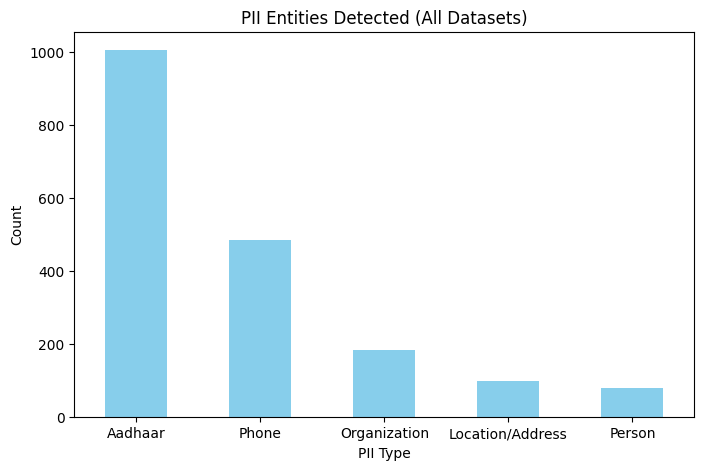

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(pii_df)
print(f"Total PII instances found: {len(results_df)}")
#counts by PII_Type
if not results_df.empty:
  counts = results_df['PII_Type'].value_counts()
  print("\nPII counts by category:")
  print(counts)
  #Plot a bar chart for PII category counts
  plt.figure(figsize=(8,5))
  counts.plot(kind='bar', color='skyblue')
  plt.title('PII Entities Detected (All Datasets)')
  plt.xlabel('PII Type')
  plt.ylabel('Count')
  plt.xticks(rotation=0)
  plt.show()

In [ ]:
output_file = "/content/drive/MyDrive/datasets-shared-by-NIC/PII_Detection_Results-KCC.csv"
results_df.to_csv(output_file, index=False)
print(f"All PII detection results have been saved to {output_file}")




All PII detection results have been saved to /content/drive/MyDrive/datasets-shared-by-NIC/PII_Detection_Results-KCC.csv


In [ ]:
df.to_csv("kcc.csv", index=False)
